# 9.1 Introduction

# 9.2 Outlier Detection and Handling Part 01

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [19]:
#Missing values
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


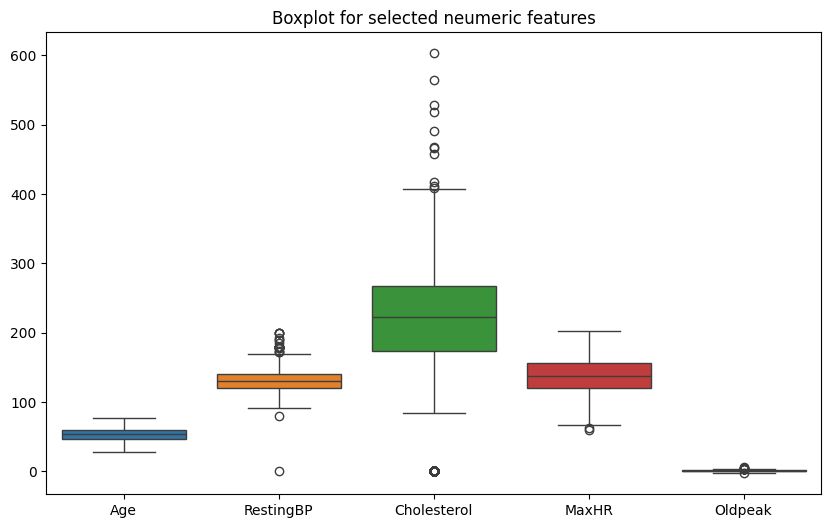

In [20]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
plt.figure(figsize=(10,6))
sns.boxplot(data = df[numeric_cols])
plt.title("Boxplot for selected neumeric features")
plt.show()

In [21]:
#Handling Outliers
# Use IQR method on cholesterol as an example
col = "Cholesterol"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

l_bound = Q1 - 1.5 * IQR
u_bound = Q3 + 1.5 * IQR

outilers = df[(df[col]<l_bound) | (df[col]>u_bound)]
print(f"Number of outliers in {col}: {len(outilers)}")



Number of outliers in Cholesterol: 183


In [22]:
outilers.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1


# 9.3 Outlier Detection and Handling Part 02

In [23]:
from sklearn.preprocessing import LabelEncoder
#Encoding befor start(from 7)
#Label Encoding for binary categorical columns -> Sex and ExerciseAngina
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["ExerciseAngina"] = le.fit_transform(df["ExerciseAngina"])
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [24]:
#OneHot Encoding for nominal categorical columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df_heart_encoded = pd.get_dummies(
    df,
    columns= cat_cols,
    dtype=int

)

df_heart_encoded.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


In [25]:
# Remove outliers
df_no_outliers = df_heart_encoded[(df_heart_encoded[col]>=l_bound) & (df_heart_encoded[col] <= u_bound)]
print(len(df_no_outliers))

735


In [26]:
#Cap outliers (winsorization-like approach)
df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(l_bound, u_bound)
print(len(df_capped))

918


In [27]:
#Log transfermation the column (f0r skewed distributions)
df_log = df_heart_encoded.copy()
df_log[col + "_log"] = np.log(df_log[col] + 1)
print(df_log)

     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140          289          0    172               0   
1     49    0        160          180          0    156               0   
2     37    1        130          283          0     98               0   
3     48    0        138          214          0    108               1   
4     54    1        150          195          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110          264          0    132               0   
914   68    1        144          193          1    141               0   
915   57    1        130          131          0    115               1   
916   57    0        130          236          0    174               0   
917   38    1        138          175          0    173               0   

     Oldpeak  HeartDisease  ChestPainType_ASY  ChestPainType_ATA  \
0        0.0             0     

# 9.4 Feature Transformation and Domain-Driven Features Part 01


In [28]:
from sklearn.preprocessing import PolynomialFeatures

#Polynomial features using Age and MaxHR (if available)
poly_cols = ["Age", "MaxHR"]
poly = PolynomialFeatures(degree = 2, include_bias= False)

poly_features = poly.fit_transform(df_heart_encoded[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

print(poly_feature_names)
print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


# 9.5 Feature Transformation and Domain-Driven Features Part 02

In [29]:
# Binning Age into categories (Yong, Middle, Middle Old, Old)

df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins = [0,30,50,70,100],
    labels = ["Yong", "Middle", "Middle Old", "Old"]
)

print(df_heart_encoded[["Age", "Age_bin"]].head(50))

    Age     Age_bin
0    40      Middle
1    49      Middle
2    37      Middle
3    48      Middle
4    54  Middle Old
5    39      Middle
6    45      Middle
7    54  Middle Old
8    37      Middle
9    48      Middle
10   37      Middle
11   58  Middle Old
12   39      Middle
13   49      Middle
14   42      Middle
15   54  Middle Old
16   38      Middle
17   43      Middle
18   60  Middle Old
19   36      Middle
20   43      Middle
21   44      Middle
22   49      Middle
23   44      Middle
24   40      Middle
25   36      Middle
26   53  Middle Old
27   52  Middle Old
28   53  Middle Old
29   51  Middle Old
30   53  Middle Old
31   56  Middle Old
32   54  Middle Old
33   41      Middle
34   43      Middle
35   32      Middle
36   65  Middle Old
37   41      Middle
38   48      Middle
39   48      Middle
40   54  Middle Old
41   54  Middle Old
42   35      Middle
43   52  Middle Old
44   43      Middle
45   59  Middle Old
46   37      Middle
47   50      Middle
48   36      Middle


# 9.6 Feature Transformation and Domain-Driven Features Part 03

In [30]:
#Domain driven Risk Categories for RestingBP and Oldpeak

def bp_risk(bp):
  if bp < 120:
    return "Normal"
  elif bp < 140:
    return "Elevated"
  else:
    return "Hight"

def Oldpeak_risk(op):
  if op ==0:
    return "No Stress"
  elif op < 2:
    return "Moderate Stress"
  else:
    return "High Stress"

#Apply to Datafra,e

df_heart_encoded["BP_Risk"] = df_heart_encoded["RestingBP"].apply(bp_risk)
df_heart_encoded["Oldpeak_risk"] = df_heart_encoded["Oldpeak"].apply(Oldpeak_risk)

df_heart_encoded[["RestingBP", "BP_Risk", "Oldpeak", "Oldpeak_risk"]]

,RestingBP,BP_Risk,Oldpeak,Oldpeak_risk
0,140,Hight,0.0,No Stress
1,160,Hight,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,Hight,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,Hight,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


# 9.7 Putting It All Together in a Preprocessing Pipeline

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Define numeric and categorical columns for the pipeline
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

#Numeric Pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

#Categorical pipeline
cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop = "first"))
])
#Combine both
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

#Full pipeline with a simple model
clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])